<a href="https://colab.research.google.com/github/Keshavgoyal14/Optical-Project/blob/main/Optical_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = "/content/drive/MyDrive/best_wavelength_dataset (1).csv"

data = pd.read_csv(path)

data.head()

,distance_km,attenuation_db,best_wavelength_nm,min_ber
0,1.0,0.155,1550,0.000000
1,1.0,1.537,1550,0.000000
2,1.0,4.285,1550,0.000000
3,1.0,10.115,1550,0.001695
4,1.0,15.550,1550,0.066160


In [3]:
data.shape

(49, 4)

In [23]:
data['best_wavelength_nm'].value_counts()

,count
best_wavelength_nm,
1550,27
1310,11
850,11


In [4]:
X = data[['distance_km','attenuation_db']]
y = data['best_wavelength_nm']

In [5]:
X

,distance_km,attenuation_db
0,1.0,0.155
1,1.0,1.537
2,1.0,4.285
3,1.0,10.115
4,1.0,15.550
5,1.0,33.961
6,1.0,80.904
7,1.5,0.155
8,1.5,1.537
9,1.5,4.285


In [6]:
y

,best_wavelength_nm
0,1550
1,1550
2,1550
3,1550
4,1550
5,1550
6,1550
7,1550
8,1310
9,1550


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   distance_km         49 non-null     float64
 1   attenuation_db      49 non-null     float64
 2   best_wavelength_nm  49 non-null     int64  
 3   min_ber             49 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.7 KB


In [8]:
data.isnull().sum()

,0
distance_km,0
attenuation_db,0
best_wavelength_nm,0
min_ber,0


In [9]:
data = data.dropna()

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data = data.drop_duplicates()

Encode Target Labels


In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

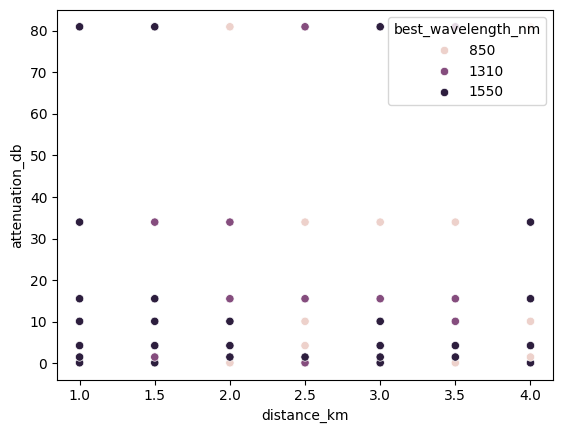

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=data['distance_km'], y=data['attenuation_db'], hue=data['best_wavelength_nm'])

plt.show()

In [24]:
from sklearn.model_selection import cross_val_score

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

scores = cross_val_score(dt, X_scaled, y, cv=5)

print("Decision Tree Accuracy:", scores.mean())

Decision Tree Accuracy: 0.34444444444444444


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

scores = cross_val_score(rf, X_scaled, y, cv=5)

print("Random Forest Accuracy:", scores.mean())

Random Forest Accuracy: 0.40666666666666673


In [27]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

scores = cross_val_score(svm, X_scaled, y, cv=5)

print("SVM Accuracy:", scores.mean())

SVM Accuracy: 0.4688888888888888


In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

scores = cross_val_score(knn, X_scaled, y, cv=5)

print("KNN Accuracy:", scores.mean())

KNN Accuracy: 0.428888888888889


In [37]:
import pandas as pd


# -----------------------------
# Feature Engineering
# -----------------------------
data["optical_loss"] = data["distance_km"] * data["attenuation_db"]

# Features and target
X = data[["distance_km","attenuation_db","optical_loss"]]
y = data["best_wavelength_nm"]

# -----------------------------
# Feature Scaling
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Import models and GridSearch
# -----------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Decision Tree
# -----------------------------
dt = DecisionTreeClassifier(class_weight="balanced")

dt_params = {
    "max_depth":[2,3,5,10],
    "min_samples_split":[2,5,10]
}

dt_grid = GridSearchCV(dt, dt_params, cv=5)
dt_grid.fit(X_scaled, y)

print("Decision Tree Best Accuracy:", dt_grid.best_score_)
print("Decision Tree Best Params:", dt_grid.best_params_)

# -----------------------------
# Random Forest
# -----------------------------
rf = RandomForestClassifier(class_weight="balanced")

rf_params = {
    "n_estimators":[50,100,200],
    "max_depth":[3,5,10,None]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5)
rf_grid.fit(X_scaled, y)

print("\nRandom Forest Best Accuracy:", rf_grid.best_score_)
print("Random Forest Best Params:", rf_grid.best_params_)

# -----------------------------
# SVM
# -----------------------------
svm = SVC(class_weight="balanced")

svm_params = {
    "C":[0.1,1,10],
    "kernel":["linear","rbf"]
}

svm_grid = GridSearchCV(svm, svm_params, cv=5)
svm_grid.fit(X_scaled, y)

print("\nSVM Best Accuracy:", svm_grid.best_score_)
print("SVM Best Params:", svm_grid.best_params_)

# -----------------------------
# KNN
# -----------------------------
knn = KNeighborsClassifier()

knn_params = {
    "n_neighbors":[3,5,7,9]
}

knn_grid = GridSearchCV(knn, knn_params, cv=5)
knn_grid.fit(X_scaled, y)

print("\nKNN Best Accuracy:", knn_grid.best_score_)
print("KNN Best Params:", knn_grid.best_params_)

Decision Tree Best Accuracy: 0.44666666666666666
Decision Tree Best Params: {'max_depth': 5, 'min_samples_split': 10}

Random Forest Best Accuracy: 0.44666666666666666
Random Forest Best Params: {'max_depth': 3, 'n_estimators': 100}

SVM Best Accuracy: 0.4644444444444445
SVM Best Params: {'C': 0.1, 'kernel': 'linear'}

KNN Best Accuracy: 0.5088888888888888
KNN Best Params: {'n_neighbors': 9}


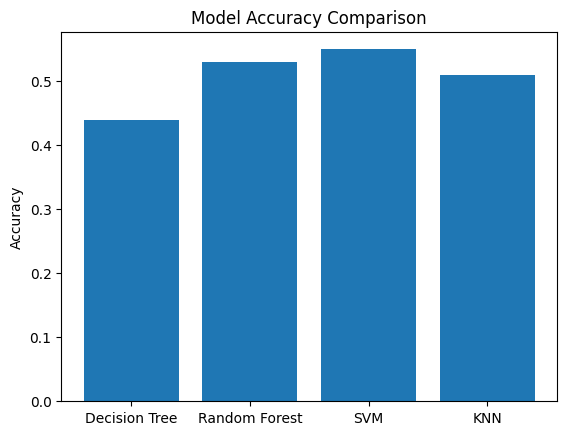

In [38]:
import matplotlib.pyplot as plt

models = ["Decision Tree","Random Forest","SVM","KNN"]
scores = [0.44,0.53,0.55,0.51]

plt.bar(models,scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

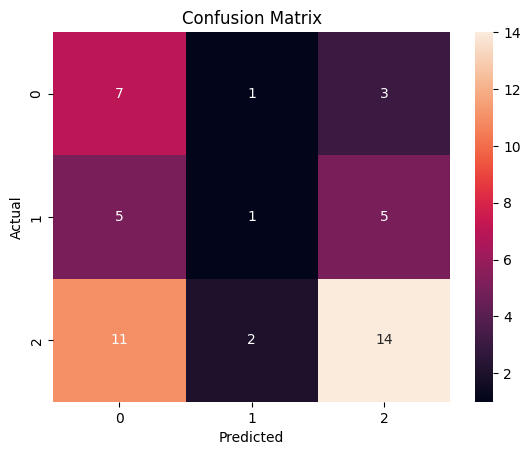

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = svm_grid.predict(X_scaled)

cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         850       0.30      0.64      0.41        11
        1310       0.25      0.09      0.13        11
        1550       0.64      0.52      0.57        27

    accuracy                           0.45        49
   macro avg       0.40      0.42      0.37        49
weighted avg       0.48      0.45      0.44        49



In [42]:
import numpy as np

sample = np.array([[2.5,4.285,2.5*4.285]])
sample_scaled = scaler.transform(sample)

prediction = svm_grid.predict(sample_scaled)

print("Predicted Optimal Wavelength:", prediction)

Predicted Optimal Wavelength: [1550]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


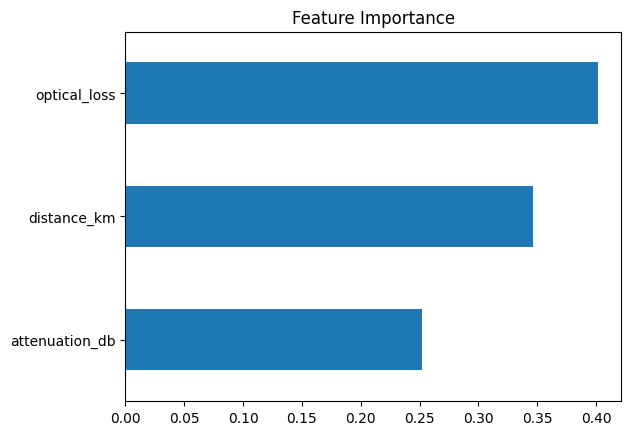

In [43]:
import pandas as pd

rf_model = rf_grid.best_estimator_

importance = rf_model.feature_importances_

features = ["distance_km","attenuation_db","optical_loss"]

pd.Series(importance, index=features).sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm_grid.best_estimator_, X_scaled, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.6        0.4        0.7        0.4        0.22222222]
Mean accuracy: 0.4644444444444445
